# **Project 2a − Alloy Cluster Expansions**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [1]:
### Imports and plotting settings ###

import ase
import icet

import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import seaborn as sns
sns.set_context('notebook')
import emcee
import corner

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import ARDRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

def running_mean(x, factor):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))
    #print(average.shape)
    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        #print((cumsum[N:] - cumsum[:-N]).shape)
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))
    average = np.sum(average,axis=1) / walker

    return average

def trace_plotter(axs, sampler, iterations, sampler_idx=None, ndim=2, save=False):
    """
    Plot the traces of the MCMC chain.

    Args:
        axs (ndarray): The axes to plot on,
        sampler (emcee.EnsembleSampler): The sampler object,
        iterations (int): The number of iterations to plot,
        sampler_idx (str): The index of the sampler,
        ndim (int): The number of dimensions of the parameter space,
        save (bool): Whether to save the figure.
    """
    
    # If we have three parameters, plot the trace of sigma as well
    if ndim == 3:
        axs[0].plot([], [], 'k')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].plot(sampler.chain[:, :iterations, 0].T, color='k', alpha=0.1)#, label='Traces $c_D$')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].set_ylabel(r'$H_0$')
        axs[0].set_xticklabels([])
        axs[1].plot([], [], 'k')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].plot(sampler.chain[:, :iterations, 1].T, color='k', alpha=0.1)#, label='Traces $c_E$')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].set_ylabel(r'$q_0$')
        axs[1].set_xticklabels([])
        axs[2].plot([], [], 'k')
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].plot(sampler.chain[:, :iterations, 2].T, color='k', alpha=0.3)
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].set_ylabel(r'$\sigma_{\mathrm{sys}}^2$')
        axs[2].set_xlabel('Sampler Iteration')
        axs[2].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)
    else:
        # If we have 3 or more parameters, plot all of them
        for i, ax in enumerate(axs):
            ax.plot([], [], 'k')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.plot(sampler.chain[:, :iterations, i].T, color='k', alpha=0.1)#, label='Traces $c_D$')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.set_ylabel(r'$J_{'+str(i)+'}$')
            # if i != len(axs) - 2:
            #     ax.set_xticklabels([])
            # else:
            #     ax.set_xlabel('Sampler Iteration')
        axs[-1].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)

    if save:
        axs[0].figure.savefig('figs/post_samples'+sampler_idx+'.pdf', bbox_inches='tight')

def find_cu_concentration(comp):
    """
    Find the copper concentration in a given composition.

    Args:
        comp (str): The composition string, e.g. 'Au3Cu1'.
    
    Returns:
        float: The copper concentration.
    """

    formula = ase.formula.Formula(comp)
    count = formula.count()
    try:
        cu_concentration = count['Cu'] / sum(count.values())
    except KeyError:
        cu_concentration = 0.0

    return cu_concentration


## **Task 1: Prepare data**

In [2]:

db = ase.db.connect('data/AuCu-structures.db')

prim = db.get(formula='AuCu').toatoms()
cs = icet.ClusterSpace(prim, cutoffs=[8, 6, 5], chemical_symbols=['Au', 'Cu'])
print(cs)

# Initialize 3-dimensional array to hold composition, energy, and structure
data = {
    'composition': [],
    'energy': [],
    'structure': []
}
for row in db.select():
    atoms = row.toatoms()
    structure = atoms.cell
    energy = row.mixing_energy
    comp = atoms.get_chemical_formula()
    data['composition'].append(comp)
    data['energy'].append(energy)
    data['structure'].append(structure)
    

====================================== Cluster Space ======================================
 space group                            : Fm-3m (225)
 chemical species                       : ['Au', 'Cu'] (sublattice A)
 cutoffs                                : 8.0000 6.0000 5.0000
 total number of parameters             : 24
 number of parameters by order          : 0= 1  1= 1  2= 7  3= 12  4= 3
 fractional_position_tolerance          : 2e-06
 position_tolerance                     : 1e-05
 symprec                                : 1e-05
-------------------------------------------------------------------------------------------
index | order |  radius  | multiplicity | orbit_index | multicomponent_vector | sublattices
-------------------------------------------------------------------------------------------
   0  |   0   |   0.0000 |        1     |      -1     |           .           |      .     
   1  |   1   |   0.0000 |        1     |       0     |          [0]          |      A     


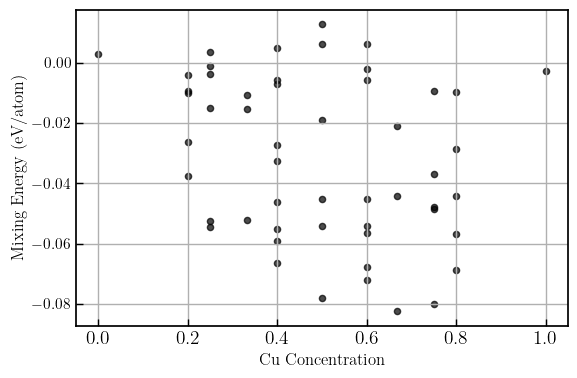

In [30]:

comps = data['composition']
energies = data['energy']

cu_concentrations = [find_cu_concentration(comp) for comp in comps]

plt.figure(figsize=(6,4))
plt.scatter(cu_concentrations, energies, color='k', s=20, alpha=0.7)
plt.xlabel('Cu Concentration')
plt.ylabel('Mixing Energy (eV/atom)')
plt.grid(True)
plt.tight_layout()
# plt.savefig('figs/au_cu_mixing_energy_vs_concentration.pdf', bbox_inches='tight')
plt.show()


## **Task 2: OLS and ridge regression**

In [ ]:

sc = icet.StructureContainer(cs)
for row in db.select():
    sc.add_structure(row.toatoms(), properties=dict(mixing_energy=row.mixing_energy))
X, E = sc.get_fit_data(key='mixing_energy')

# Standardize features
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)
scaler_E = StandardScaler()
E_std = scaler_E.fit_transform(E.reshape(-1, 1)).flatten()

# OLS regression
ols = LinearRegression(fit_intercept=False)
ols.fit(X_std, E_std)
J_opt_OLS_std = ols.coef_

# Ridge regression, use K-fold cross validation to find optimal value for alpha
alphas = np.logspace(-5, 5, 100)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
ridge_cv = RidgeCV(alphas=alphas, fit_intercept=False, cv=kf)
ridge_cv.fit(X_std, E_std)
alpha_opt = ridge_cv.alpha_
print(f'Optimal alpha for Ridge regression: {alpha_opt}')

ridge = Ridge(alpha=alpha_opt, fit_intercept=False)
ridge.fit(X_std, E_std)
J_opt_ridge_std = ridge.coef_


Optimal alpha for Ridge regression: 0.10974987654930568


In [ ]:

# X_recovered = scaler_X.inverse_transform(X_std)
# E_recovered = scaler_E.inverse_transform(E_std.reshape(-1, 1)).flatten()

# Compute CV-RMSE for both models
scores_ols = cross_val_score(ols, X_std, E_std, cv=kf, scoring='neg_root_mean_squared_error')
rmse_ols = -np.mean(scores_ols)
print(f'OLS CV-RMSE: {rmse_ols:.4f} eV/atom')

scores_ridge = cross_val_score(ridge, X_std, E_std, cv=kf, scoring='neg_root_mean_squared_error')
rmse_ridge = -np.mean(scores_ridge)
print(f'Ridge CV-RMSE: {rmse_ridge:.4f} eV/atom')


OLS CV-RMSE: 0.1060 eV/atom
Ridge CV-RMSE: 0.1057 eV/atom


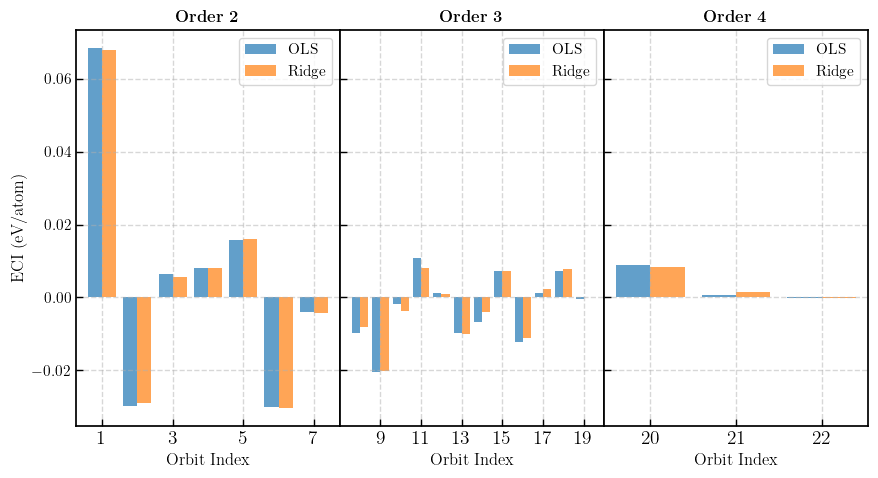

In [68]:

J_opt_OLS_recovered = J_opt_OLS_std / scaler_X.scale_ * scaler_E.scale_
intercept_OLS = scaler_E.mean_ - scaler_X.mean_ @ J_opt_OLS_recovered
J_opt_ridge_recovered = J_opt_ridge_std / scaler_X.scale_ * scaler_E.scale_
intercept_ridge = scaler_E.mean_ - scaler_X.mean_ @ J_opt_ridge_recovered

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(9, 5))
width = 0.4
df_cs = cs.to_dataframe()
cluster_orders = df_cs['order'].values
cluster_indices = df_cs['orbit_index'].values

for order, ax in enumerate(axes, start=2):
    index = cluster_orders == order
    ax.bar(cluster_indices[index] - width/2, J_opt_OLS_recovered[index], width=width, label='OLS', color='tab:blue', alpha=0.7)
    ax.bar(cluster_indices[index] + width/2, J_opt_ridge_recovered[index], width=width, label='Ridge', color='tab:orange', alpha=0.7)
    ax.set_xlabel('Orbit Index')
    ax.set_title(f'\\textbf{{Order {order}}}')
    if order == 2:
        ax.set_ylabel('ECI (eV/atom)')
        ax.set_xticks([1, 3, 5, 7])
    elif order == 3:
        ax.set_xticks([9, 11, 13, 15, 17, 19])
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.align_ylabels(axes)


## **Task 3: Covariance matrix for cluster similarity**

In [63]:

def Lambda_mat(gammas, cs_df):
    n_orbits = len(cs_df['orbit_index'])
    Lambda = np.zeros((n_orbits, n_orbits))
    gamma1, gamma2 = gammas

    for i in range(n_orbits):
        radius = cs_df['radius'][i]
        sites = cs_df['order'][i]
        Lambda[i, i] = gamma1 * radius + gamma2 * sites

    return Lambda

def mod_ridge(X, E, Lambda):

    A = X.T @ X + Lambda
    b = X.T @ E
    J = np.linalg.pinv(A) @ b
    return J

def cv_rmse(gammas, cs_df, X, E, k=5):
    Lambda = Lambda_mat(gammas, cs_df)
    rmses = []

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        E_train, E_val = E[train_idx], E[val_idx]

        J_cv = mod_ridge(X_train, E_train, Lambda)
        E_pred = X_val @ J_cv

        rmse = np.sqrt(np.mean((E_val - E_pred)**2))
        rmses.append(rmse)

    return np.mean(rmses)

cs_df = cs.to_dataframe()
gammas0 = [0.1, 0.1]
gammas_star = scipy.optimize.minimize(cv_rmse, gammas0, args=(cs_df, X_std, E_std)).x#, method='Powell').x

print(f'Optimal gammas: {gammas_star}')
print(f'CV-RMSE with optimal gammas: {cv_rmse(gammas_star, cs_df, X_std, E_std):.4f} eV/atom')

Optimal gammas: [0.04386363 0.13648877]
CV-RMSE with optimal gammas: 0.1063 eV/atom


## **Task 4: Bayesian Cluster expansion**

In [134]:

def log_prior(params):
    """
    Calculate the log prior probability.

    Args:
        params (list): The parameters [gamma_radius, gamma_sites].

    Returns:
        float: The log prior probability.
    """
    J, s2, alpha = params[:-2], params[-2], params[-1]
    if s2 <= 0.02**2 or s2 >= 4 or alpha <= 0.05 or alpha >= 0.5:
        return -np.inf
    lp_s2 = scipy.stats.invgamma.logpdf(s2, a=2, scale=0.05)
    lp_alpha = scipy.stats.invgamma.logpdf(alpha, a=2, scale=0.1)
    lp_J = - len(J) / 2 * np.log(2 * np.pi * alpha**2) - np.sum(np.linalg.norm(J) ** 2) / (2 * alpha**2)

    return lp_s2 + lp_alpha + lp_J

def log_likelihood(params, X, E):
    """
    Calculate the log likelihood.

    Args:
        params (list): The parameters [J, s2, alpha],
        X (ndarray): The feature matrix,
        E (ndarray): The target values.

    Returns:
        float: The log likelihood.
    """
    n_samples = X.shape[0]
    J, s2, alpha = params[:-2], params[-2], params[-1]
    E_pred = X @ J
    residuals = E - E_pred
    ll = - n_samples / 2 * np.log(2 * np.pi * s2) - np.sum(residuals ** 2) / (2 * s2)

    return ll

def log_posterior(params, X, E):
    """
    Calculate the log posterior probability.

    Args:
        params (list): The parameters [J, s2, alpha],
        X (ndarray): The feature matrix,
        E (ndarray): The target values.

    Returns:
        float: The log posterior probability.
    """
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(params, X, E)

    return lp + ll


  0%|          | 0/5000 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [03:34<00:00, 23.28it/s]


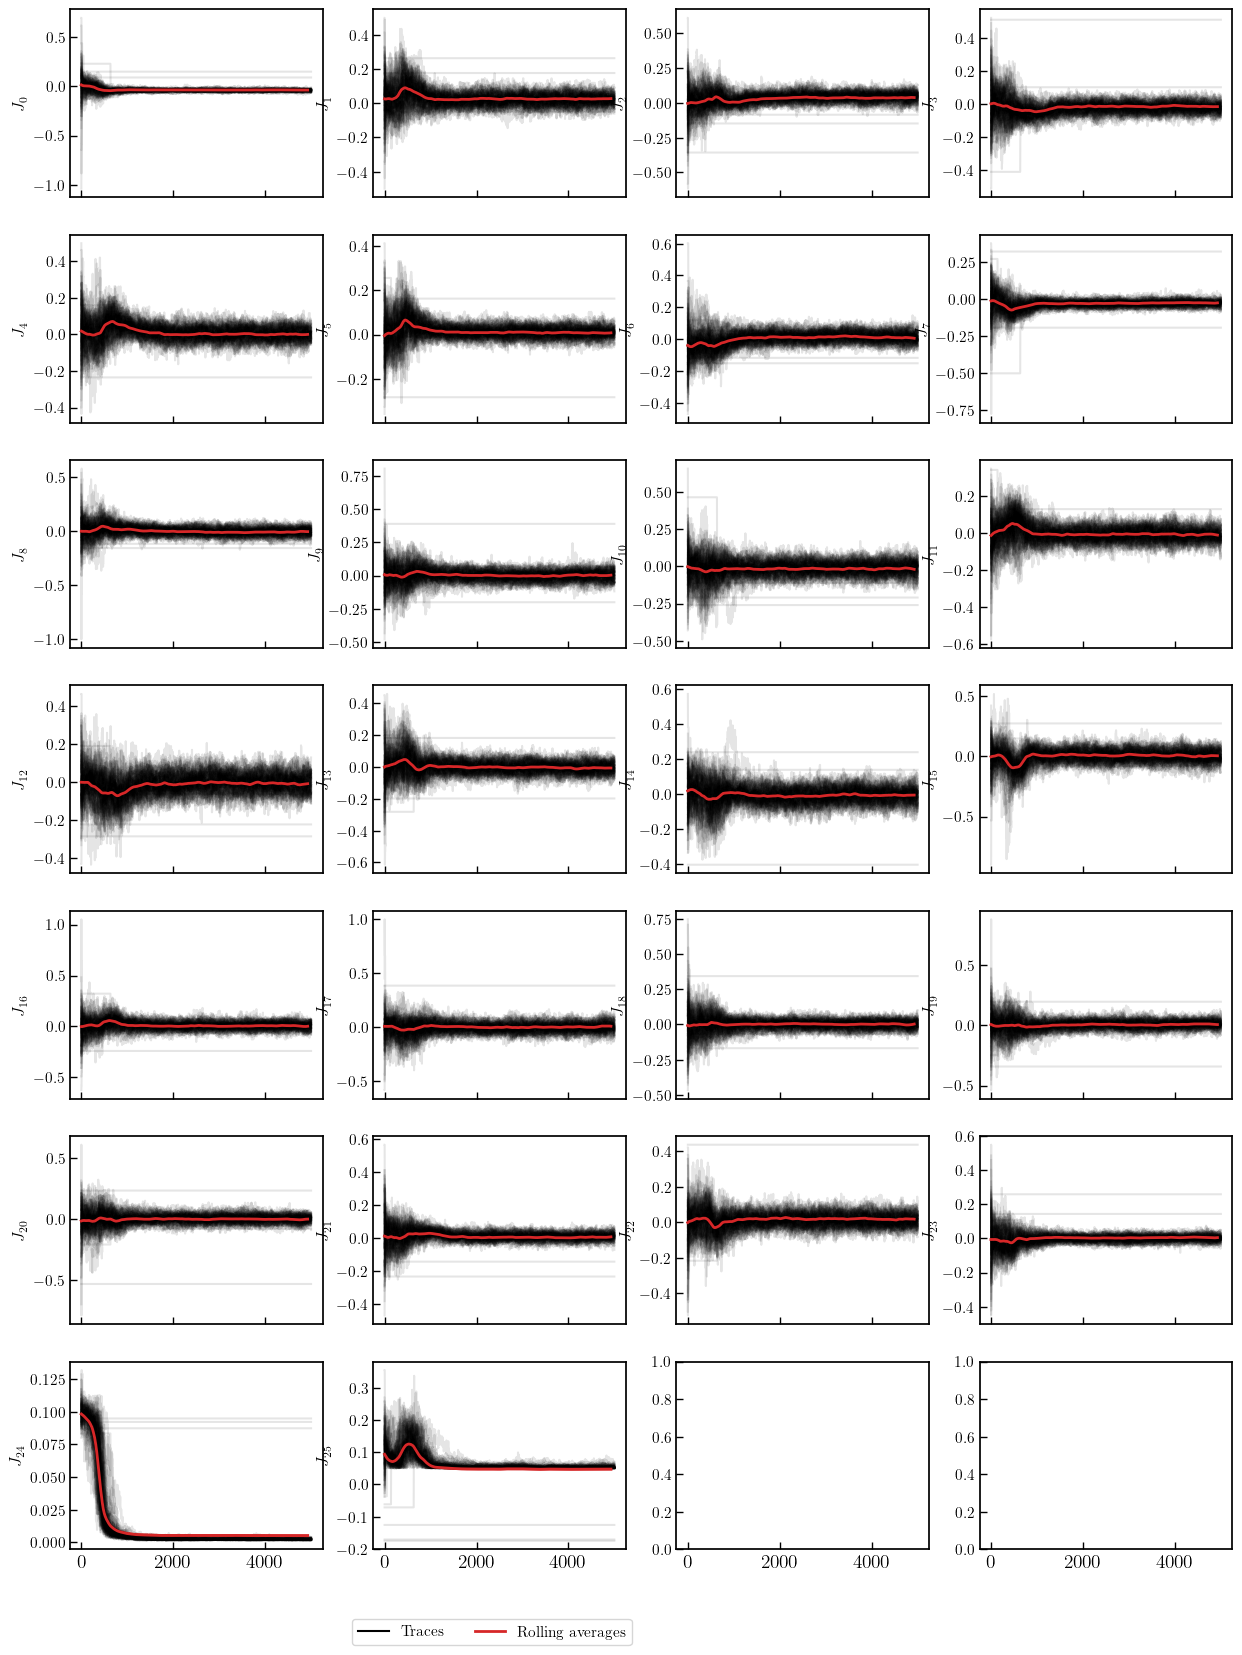

In [165]:

file = 'chain_task3.h5'
if os.path.exists(file):
    os.remove(file)

n_walkers = 100
n_steps_burn = 5000
ndim = 2 + len(J_opt_ridge_std)  # J, sigma_sys^2, alpha = 26
p0 = np.zeros((n_walkers, ndim))
p0[:, :len(J_opt_ridge_std)] = np.random.normal(loc=0, scale=0.2, size=(n_walkers, len(J_opt_ridge_std))) # J
p0[:, len(J_opt_ridge_std)] = np.random.normal(loc=0.1, scale=0.01, size=n_walkers) # sigma_sys^2
p0[:, len(J_opt_ridge_std) + 1] = np.random.normal(loc=0.1, scale=0.1, size=n_walkers) # alpha

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_posterior, backend=emcee.backends.HDFBackend('chain_task3.h5'), args=(X_recovered, E_recovered))
pos, prob, state = sampler.run_mcmc(p0, n_steps_burn, progress=True)

fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20), sharex=True)
trace_plotter(axs.flatten()[:-2], sampler, iterations=n_steps_burn, sampler_idx='_task3', ndim=ndim, save=False)


In [166]:

sampler.reset()
final_pos, final_prob, final_state = sampler.run_mcmc(pos, 500, progress=True)


  0%|          | 0/500 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 500/500 [00:19<00:00, 25.20it/s]


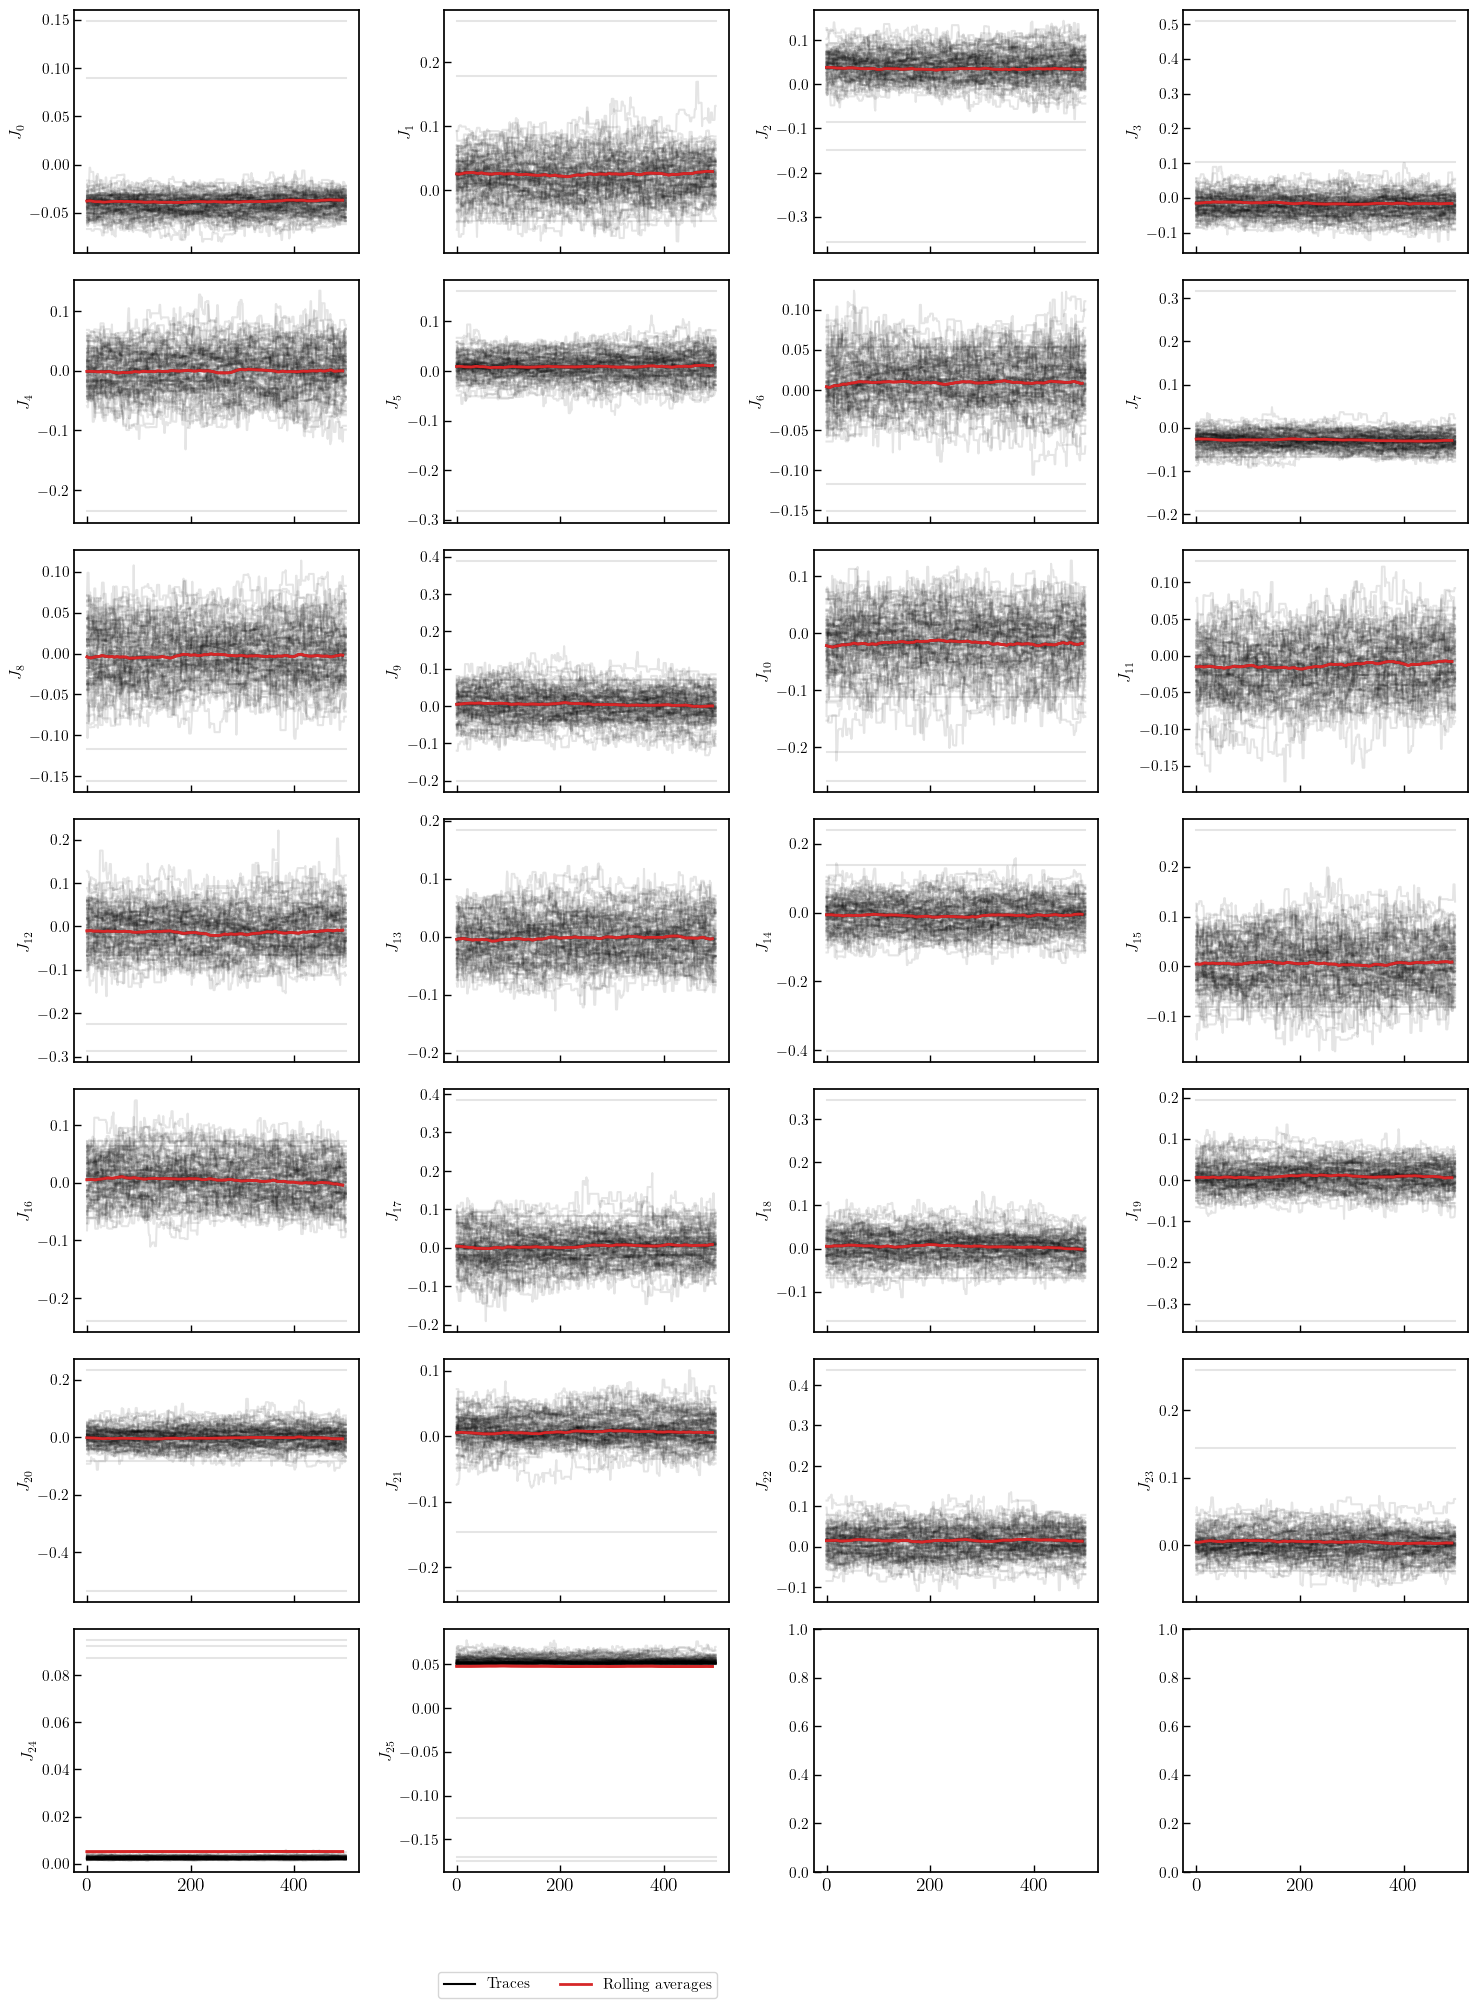

In [167]:

fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20), sharex=True)
trace_plotter(axs.flatten()[:-2], sampler, iterations=500, sampler_idx='_task3', ndim=ndim, save=False)

plt.tight_layout()
plt.show()


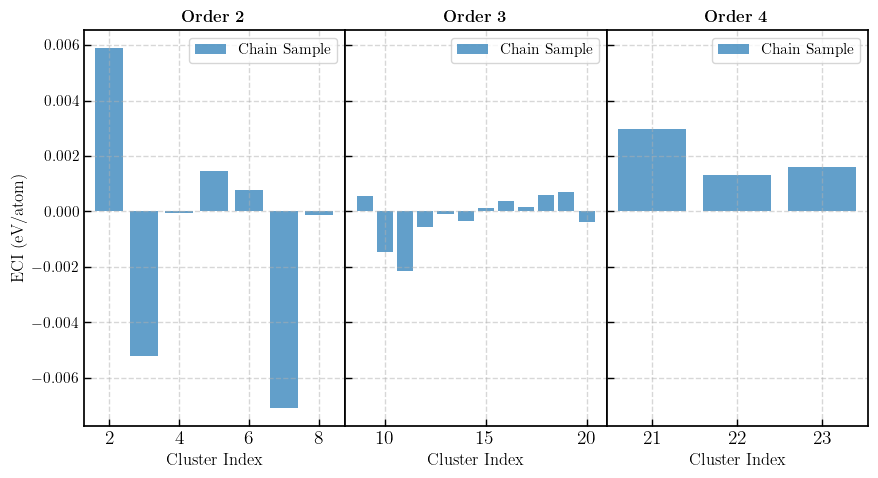

In [169]:

# Visualize ECIs for a chain sample
samples = sampler.get_chain(flat=True)
J_samples = samples[:, :-2]
J_mean = np.mean(J_samples, axis=0)
ce = icet.ClusterExpansion(parameters=J_mean, cluster_space=cs)
df_ce = ce.to_dataframe()

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(9, 5))

for order, ax in enumerate(axes, start=2):
    df_ce_order = df_ce[df_ce['order'] == order]

    ax.bar(df_ce_order.index, df_ce_order['eci'], label='Chain Sample', color='tab:blue', alpha=0.7)
    ax.set_xlabel('Cluster Index')
    ax.set_title(f'\\textbf{{Order {order}}}')
    if order == 2:
        axes[0].set_ylabel('ECI (eV/atom)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.align_ylabels(axes)


## **Task 5: ARDR Feature selection**

In [69]:

prim_ardr = db.get(formula='AuCu').toatoms()
cs_ardr = icet.ClusterSpace(prim_ardr, cutoffs=[13, 8, 6], chemical_symbols=['Au', 'Cu'])

sc_ardr = icet.StructureContainer(cs_ardr)
for row in db.select():
    sc_ardr.add_structure(row.toatoms(), properties=dict(mixing_energy=row.mixing_energy))
X_ardr, E_ardr = sc_ardr.get_fit_data(key='mixing_energy')

# Standardize features
scaler_X = StandardScaler()
X_ardr = scaler_X.fit_transform(X_ardr)
scaler_E = StandardScaler()
E_ardr = scaler_E.fit_transform(E_ardr.reshape(-1, 1)).flatten()

lambda_thresholds = np.logspace(-5, 5, 2000)

res_dict = {
    'lambda': [],
    'training_rmse': [],
    'cv_rmse': [],
    'n_nonzero_ecis': [],
    'bic': [],
    'aic': []
}
for lam in lambda_thresholds:
    ard = ARDRegression(threshold_lambda=lam, fit_intercept=False)
    ard.fit(X_ardr, E_ardr)
    training_error = np.sqrt(np.mean((E_ardr - ard.predict(X_ardr))**2))
    cv_error = np.sqrt(-cross_val_score(ard, X_ardr, E_ardr, cv=5, scoring='neg_mean_squared_error').mean())
    n_nonzero = np.sum(ard.coef_ != 0)
    aic = - 2 * n_nonzero - len(E_ardr) * np.log(training_error**2)
    bic = - n_nonzero * np.log(len(E_ardr)) - len(E_ardr) * np.log(training_error**2)
    res_dict['lambda'].append(lam)
    res_dict['training_rmse'].append(training_error)
    res_dict['cv_rmse'].append(cv_error)
    res_dict['n_nonzero_ecis'].append(n_nonzero)
    res_dict['bic'].append(bic)
    res_dict['aic'].append(aic)
    

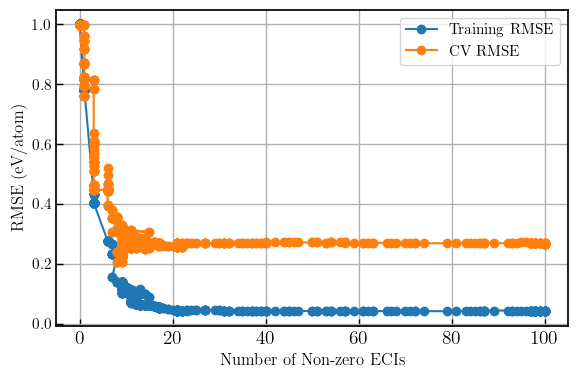

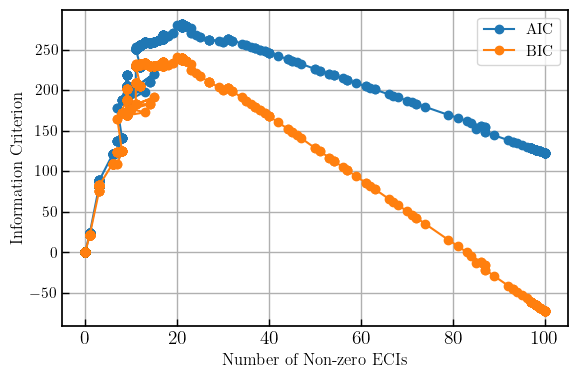

In [70]:

plt.figure(figsize=(6,4))
plt.plot(res_dict['n_nonzero_ecis'], res_dict['training_rmse'], label='Training RMSE', marker='o')
plt.plot(res_dict['n_nonzero_ecis'], res_dict['cv_rmse'], label='CV RMSE', marker='o')
plt.xlabel('Number of Non-zero ECIs')
plt.ylabel('RMSE (eV/atom)')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('figs/ardr_rmse_vs_n_nonzero_ecis.pdf', bbox_inches='tight')

plt.figure(figsize=(6,4))
plt.plot(res_dict['n_nonzero_ecis'], res_dict['aic'], label='AIC', marker='o')
plt.plot(res_dict['n_nonzero_ecis'], res_dict['bic'], label='BIC', marker='o')
plt.xlabel('Number of Non-zero ECIs')
plt.ylabel('Information Criterion')
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig('figs/ardr_ic_vs_n_nonzero_ecis.pdf', bbox_inches='tight')
plt.show()

## **Task 6: The ground state**

In [102]:

db_gs = ase.db.connect('data/ground-state-candidates.db')

candidate_structs = []
candidate_ids = []
X_gs_raw = []

for row in db_gs.select():
    atoms = row.toatoms()
    candidate_structs.append(atoms)
    candidate_ids.append(row.id)
    X_gs_raw.append(cs.get_cluster_vector(atoms))

X_gs_raw = np.array(X_gs_raw)
X_gs = scaler_X.transform(X_gs_raw)


In [110]:

# Predict ground state energies using OLS and Ridge

ols_gs = LinearRegression(fit_intercept=False)
ols_gs.coef_ = J_opt_OLS
ols_gs.intercept_ = 0.0
ridge_gs = Ridge(alpha=alpha_opt, fit_intercept=False)
ridge_gs.coef_ = J_opt_ridge
ridge_gs.intercept_ = 0.0

E_pred_ols = ols_gs.predict(X_gs)
E_pred_ridge = ridge_gs.predict(X_gs)
E_pred_ols = scaler_E.inverse_transform(E_pred_ols.reshape(-1, 1)).flatten()
E_pred_ridge = scaler_E.inverse_transform(E_pred_ridge.reshape(-1, 1)).flatten()

# Identify ground state structures
min_energy_ols = np.min(E_pred_ols)
min_energy_ridge = np.min(E_pred_ridge)
ground_state_ols = candidate_ids[np.argmin(E_pred_ols)]
ground_state_ridge = candidate_ids[np.argmin(E_pred_ridge)]

print(f'Ground State Structure (OLS): ID {ground_state_ols} with Energy {min_energy_ols:.4f} eV/atom')
print(f'Ground State Structure (Ridge): ID {ground_state_ridge} with Energy {min_energy_ridge:.4f} eV/atom')


Ground State Structure (OLS): ID 4 with Energy -0.1170 eV/atom
Ground State Structure (Ridge): ID 4 with Energy -0.1168 eV/atom
